# Ransomware Detection Using Logistic Regression Classification
**CCE105 – Project Proposal / Model Development Notebook**

This notebook covers dataset acquisition, data cleaning, data transformation,
feature selection, feature engineering, data splitting, and the initial
configuration of a Logistic Regression **binary classifier** for detecting
ransomware from static PE (Portable Executable) file header features.

- **Task type:** binary classification (2 classes only)
- **Positive/negative classes:** `Benign = 1` (benign file) vs. `Benign = 0` (ransomware)
- **Algorithm:** Logistic Regression (`sklearn.linear_model.LogisticRegression`)
- **Dataset:** *ransomware detection dataset* by A. Bensalah, Kaggle
  (`amdj3dax/ransomware-detection-data-set`).


## 1. Setup and Dataset Acquisition

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")


In [3]:
EXPECTED_COLUMNS = [
    "FileName", "md5Hash", "Machine", "DebugSize", "DebugRVA",
    "MajorImageVersion", "MajorOSVersion", "ExportRVA", "ExportSize",
    "IatVRA", "MajorLinkerVersion", "MinorLinkerVersion",
    "NumberOfSections", "SizeOfStackReserve", "DllCharacteristics",
    "ResourceSize", "BitcoinAddresses", "Benign",
]

def _make_synthetic_sample(n=4000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    benign = rng.binomial(1, 0.435, size=n)
    df = pd.DataFrame({
        "FileName": [f"file_{i}.exe" for i in range(n)],
        "md5Hash": [f"{rng.integers(1e15, 9e15):x}" for _ in range(n)],
        "Machine": rng.choice([332, 34404], size=n),  # 0x14c (x86), 0x8664 (x64)
        "DebugSize": rng.integers(0, 200, size=n) + (1 - benign) * rng.integers(0, 50, size=n),
        "DebugRVA": rng.integers(0, 500000, size=n),
        "MajorImageVersion": rng.integers(0, 10, size=n),
        "MajorOSVersion": rng.choice([4, 5, 6, 10], size=n),
        "ExportRVA": rng.integers(0, 500000, size=n) * benign,
        "ExportSize": rng.integers(0, 5000, size=n) * benign,
        "IatVRA": rng.integers(0, 500000, size=n),
        "MajorLinkerVersion": rng.integers(2, 15, size=n),
        "MinorLinkerVersion": rng.integers(0, 30, size=n),
        "NumberOfSections": rng.integers(2, 10, size=n) + (1 - benign),
        "SizeOfStackReserve": rng.choice([1048576, 262144, 2097152], size=n),
        "DllCharacteristics": rng.choice([0, 256, 320, 33088, 33344], size=n),
        "ResourceSize": rng.integers(0, 200000, size=n),
        "BitcoinAddresses": rng.poisson(0.05 + (1 - benign) * 0.4, size=n),
        "Benign": benign,
    })
    return df[EXPECTED_COLUMNS]


DATA_SOURCE = "synthetic-fallback"
df = None
try:
    import kagglehub
    path = kagglehub.dataset_download("amdj3dax/ransomware-detection-data-set")
    csv_candidates = [f for f in os.listdir(path) if f.lower().endswith(".csv")]
    if not csv_candidates:
        raise FileNotFoundError("No CSV file found in downloaded dataset path.")
    df = pd.read_csv(os.path.join(path, csv_candidates[0]))
    DATA_SOURCE = "kagglehub"
except Exception as exc:
    print(f"[info] Falling back to synthetic sample data ({exc.__class__.__name__}: {exc}).")
    df = _make_synthetic_sample()

print(f"Data source : {DATA_SOURCE}")
print(f"Shape       : {df.shape}")
df.head(10)


100%|██████████| 2.13M/2.13M [00:00<00:00, 85.8MB/s]

Extracting files...


Data source : kagglehub
Shape       : (62485, 18)


,FileName,md5Hash,Machine,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,SizeOfStackReserve,DllCharacteristics,ResourceSize,BitcoinAddresses,Benign
0,0124e21d-018c-4ce0-92a3-b9e205a76bc0.dll,79755c51e413ed3c6be4635fd729a6e1,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
1,05c8318f98a5d301d80000009c316005.vertdll.dll,95e19f3657d34a432eada93221b0ea16,34404,84,121728,10,10,126576,4930,0,14,10,8,262144,16864,1024,0,1
2,06054fba-5619-4a86-a861-ffb0464bef5d.dll,85c32641d77a54e19ba8ea4ab305c791,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
3,075822ac99a5d301660400009c316005.adhapi.dll,62e3b959d982ef534b66f819fe15f085,34404,84,19904,10,10,21312,252,18160,14,10,6,262144,16736,1040,0,1
4,090607dd9ba5d301ca0900009c316005.SensorsNative...,ae38c5f7d313ad0ff3bfb8826476767f,34404,84,97728,10,10,105792,1852,70592,14,10,7,262144,16736,1096,0,1
5,0aedb43f9ba5d3014e0600009c316005.wlanapi.dll,28c98e000d02f8bfd9d050eb4e4c5d2e,34404,84,319776,10,10,374944,9208,312608,14,10,7,262144,16736,2072,0,1
6,0bc194f9-b102-4833-85bd-603e216a9274.dll,706463ecc8e48e9e3a2a12a0cfcb8858,332,0,0,0,4,0,0,8192,8,0,3,1048576,34112,672,0,1
7,0c7f9fdc9ba5d301c60900009c316005.wscsvc.dll,39da352fad220e83ce64de8dccb9736b,34404,84,197888,10,10,229024,112,187208,14,10,7,262144,16736,1328,0,1
8,1.0.154_chromesetup_154_59.exe,e11e70ba243800626d17e3ffa6c9fb71,332,28,4240,0,4,0,0,4096,8,0,3,1048576,256,8799820,0,1
9,1035f45d9ca5d3015b0a00009c316005.srclient.dll,a5a106d5d03e6e59b0282e72bc9420f1,34404,84,64704,10,10,67632,404,57648,14,10,6,262144,16736,1072,0,1


## 2. Initial Data Inspection
Basic structural checks before any cleaning: data types, missing values, duplicate
records, and class balance of the target variable (`Benign`: 1 = benign, 0 = ransomware).

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62485 entries, 0 to 62484
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   FileName            62485 non-null  object
 1   md5Hash             62485 non-null  object
 2   Machine             62485 non-null  int64 
 3   DebugSize           62485 non-null  int64 
 4   DebugRVA            62485 non-null  int64 
 5   MajorImageVersion   62485 non-null  int64 
 6   MajorOSVersion      62485 non-null  int64 
 7   ExportRVA           62485 non-null  int64 
 8   ExportSize          62485 non-null  int64 
 9   IatVRA              62485 non-null  int64 
 10  MajorLinkerVersion  62485 non-null  int64 
 11  MinorLinkerVersion  62485 non-null  int64 
 12  NumberOfSections    62485 non-null  int64 
 13  SizeOfStackReserve  62485 non-null  int64 
 14  DllCharacteristics  62485 non-null  int64 
 15  ResourceSize        62485 non-null  int64 
 16  BitcoinAddresses    62

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print()
unique_labels = sorted(df["Benign"].unique().tolist())
assert unique_labels == [0, 1], f"Expected a binary target {{0, 1}}, found {unique_labels}"
print(f"Target classes confirmed binary: {unique_labels}")
print()
print("Class balance (Benign):")
print(df["Benign"].value_counts(normalize=True).rename("proportion"))


Missing values per column:
FileName              0
md5Hash               0
Machine               0
DebugSize             0
DebugRVA              0
MajorImageVersion     0
MajorOSVersion        0
ExportRVA             0
ExportSize            0
IatVRA                0
MajorLinkerVersion    0
MinorLinkerVersion    0
NumberOfSections      0
SizeOfStackReserve    0
DllCharacteristics    0
ResourceSize          0
BitcoinAddresses      0
Benign                0
dtype: int64

Exact duplicate rows: 0

Target classes confirmed binary: [0, 1]

Class balance (Benign):
Benign
0    0.566008
1    0.433992
Name: proportion, dtype: float64


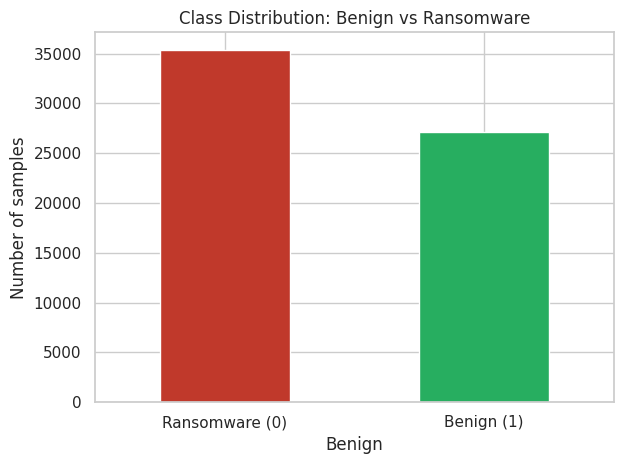

In [6]:
ax = df["Benign"].value_counts().sort_index().plot(kind="bar", color=["#c0392b", "#27ae60"])
ax.set_xticklabels(["Ransomware (0)", "Benign (1)"], rotation=0)
ax.set_ylabel("Number of samples")
ax.set_title("Class Distribution: Benign vs Ransomware")
plt.tight_layout()
plt.show()


## 3. Data Cleaning
- Drop exact duplicate rows.
- Check for duplicate `md5Hash` values (same binary appearing more than once) and drop them.
- Drop `FileName` and `md5Hash`: these are unique file identifiers, not generalizable
  predictive features, and keeping them would let the model "memorize" filenames
  instead of learning structural PE-header patterns.
- Confirm there are no missing values remaining and that numeric columns have
  sensible (non-negative) ranges.

In [7]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset="md5Hash", keep="first")
after = len(df_clean)
print(f"Removed {before - after} duplicate/redundant rows ({before} -> {after}).")

id_columns = ["FileName", "md5Hash"]
df_clean = df_clean.drop(columns=id_columns)
assert df_clean.isnull().sum().sum() == 0, "Unexpected missing values after cleaning."
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("Benign")
negative_counts = (df_clean[numeric_cols] < 0).sum()
print("Columns with negative values (should be none):")
print(negative_counts[negative_counts > 0])

df_clean.reset_index(drop=True, inplace=True)
df_clean.shape


Removed 0 duplicate/redundant rows (62485 -> 62485).
Columns with negative values (should be none):
Series([], dtype: int64)


(62485, 16)

## 4. Feature Engineering
Domain-informed binary indicator features derived from raw PE-header attributes.
These flag the *presence* of a structural characteristic rather than its exact size,
which can make weak/rare signals (like an embedded Bitcoin address) easier for the
model to exploit alongside the continuous features.

In [8]:
df_feat = df_clean.copy()

df_feat["HasDebugInfo"] = (df_feat["DebugSize"] > 0).astype(int)
df_feat["HasExportTable"] = (df_feat["ExportSize"] > 0).astype(int)
df_feat["HasBitcoinAddress"] = (df_feat["BitcoinAddresses"] > 0).astype(int)
df_feat["LinkerVersion"] = df_feat["MajorLinkerVersion"] + df_feat["MinorLinkerVersion"] / 10.0

df_feat.filter(like="Has").sum()


,0
HasDebugInfo,25964
HasExportTable,20451
HasBitcoinAddress,1125


## 5. Data Transformation
- Encode the categorical `Machine` field (target/architecture code) with one-hot encoding.
- Standardize continuous numeric features with `StandardScaler`. This step is
  required here, not just good practice: Logistic Regression is a linear model
  fit by gradient-based optimization, so unscaled features with large numeric
  ranges (e.g. `DebugRVA`, `IatVRA`) would dominate the learned coefficients and
  slow or destabilize convergence.

In [9]:
df_trans = pd.get_dummies(df_feat, columns=["Machine"], prefix="Machine")

target_col = "Benign"
feature_cols = [c for c in df_trans.columns if c != target_col]

numeric_cols_to_scale = df_trans[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
df_trans_scaled = df_trans.copy()
df_trans_scaled[numeric_cols_to_scale] = scaler.fit_transform(df_trans[numeric_cols_to_scale])

df_trans_scaled.head()


,DebugSize,DebugRVA,MajorImageVersion,MajorOSVersion,ExportRVA,ExportSize,IatVRA,MajorLinkerVersion,MinorLinkerVersion,NumberOfSections,...,HasDebugInfo,HasExportTable,HasBitcoinAddress,LinkerVersion,Machine_0,Machine_332,Machine_452,Machine_870,Machine_34404,Machine_43620
0,-0.004004,-0.081004,-0.052767,-0.557274,-0.023689,-0.014358,-0.123099,-0.197036,-0.389552,-0.818853,...,-0.843169,-0.69752,-0.135405,-0.263547,False,True,False,False,False,False
1,-0.003991,-0.017042,-0.043791,1.801516,-0.020340,-0.014185,-0.130383,0.466161,0.199503,1.519161,...,1.186002,1.43365,-0.135405,0.491318,False,False,False,False,True,False
2,-0.004004,-0.081004,-0.052767,-0.557274,-0.023689,-0.014358,-0.123099,-0.197036,-0.389552,-0.818853,...,-0.843169,-0.69752,-0.135405,-0.263547,False,True,False,False,False,False
3,-0.003991,-0.070546,-0.043791,1.801516,-0.023125,-0.014349,-0.114235,0.466161,0.199503,0.583955,...,1.186002,1.43365,-0.135405,0.491318,False,False,False,False,True,False
4,-0.003991,-0.029653,-0.043791,1.801516,-0.020890,-0.014293,-0.067613,0.466161,0.199503,1.051558,...,1.186002,1.43365,-0.135405,0.491318,False,False,False,False,True,False


## 6. Feature Selection
Inspect pairwise correlation among numeric features to spot redundant attributes,
then keep a model-coefficient-based ranking step (run after a baseline Logistic
Regression model is trained) as the primary selection method: the absolute value
of each standardized feature's coefficient directly measures its contribution to
the predicted log-odds of a file being ransomware.

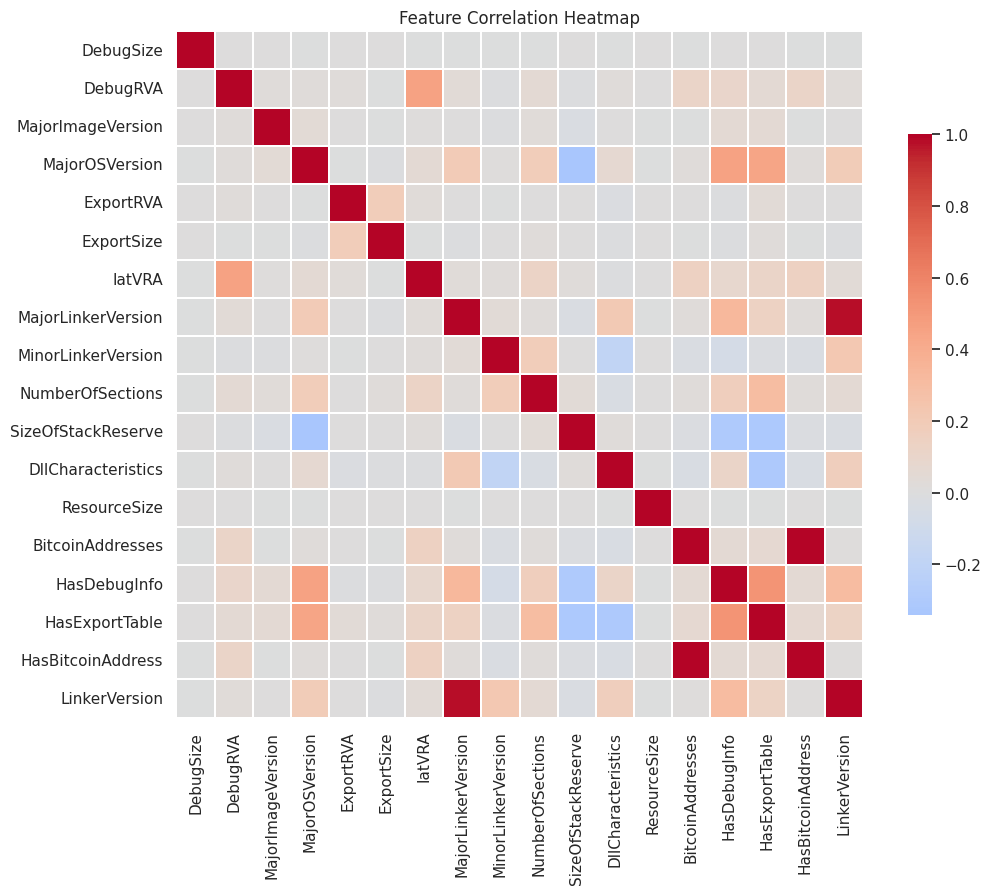

Highly correlated feature pairs (|r| > 0.9):
MajorLinkerVersion  LinkerVersion        0.983129
BitcoinAddresses    HasBitcoinAddress    1.000000
dtype: float64


In [10]:
plt.figure(figsize=(11, 9))
corr = df_trans[feature_cols].select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
high_corr = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .pipe(lambda s: s[s.abs() > 0.9])
)
print("Highly correlated feature pairs (|r| > 0.9):")
print(high_corr if not high_corr.empty else "None found.")


## 7. Data Splitting
Stratified train/test split (80% train, 20% test) to preserve the benign/ransomware
class ratio in both sets. Stratified K-Fold cross-validation is set up as well for a
more robust performance estimate during model tuning.

In [11]:
X = df_trans_scaled[feature_cols]
y = df_trans_scaled[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:")
print(y_train.value_counts(normalize=True))


Train shape: (49988, 24), Test shape: (12497, 24)
Train class balance:
Benign
0    0.566016
1    0.433984
Name: proportion, dtype: float64


## 8. Model Development — Logistic Regression Binary Classifier
A baseline `LogisticRegression` model is trained first, followed by a small
`GridSearchCV` hyperparameter search (kept intentionally narrow for now — this is
the proposal/initial-configuration stage; the search space will be expanded once
the full dataset and baseline results are available). The target has exactly two
classes (`0` = ransomware, `1` = benign), so this is a binary — not multi-class —
classification model, and metrics below are computed accordingly (e.g. `average`
defaults to binary in scikit-learn's precision/recall/F1). Logistic Regression
requires the standardized feature matrix built in Section 5 to train reliably.

In [12]:
assert y_train.nunique() == 2 and y_test.nunique() == 2, "Expected exactly 2 classes for binary classification."

baseline_logreg = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
baseline_logreg.fit(X_train, y_train)

baseline_pred = baseline_logreg.predict(X_test)
print("Baseline Logistic Regression — test accuracy:", accuracy_score(y_test, baseline_pred))


Baseline Logistic Regression — test accuracy: 0.9066976074257822


In [13]:
param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

best_logreg = grid_search.best_estimator_


Best parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-score: 0.8985857220891997


## 9. Evaluation
Expected evaluation metrics for this project: **accuracy, precision, recall,
F1-score, a confusion matrix**, and **ROC-AUC**, plus a **feature importance**
ranking to interpret which PE-header attributes drive the model's predictions.

In [14]:
y_pred = best_logreg.predict(X_test)
y_proba = best_logreg.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred, target_names=["Ransomware", "Benign"]))


Accuracy : 0.9101384332239738
Precision: 0.8649244866791108
Recall   : 0.9397123893805309
F1-score : 0.9007687549703985
ROC-AUC  : 0.9604854708399176

              precision    recall  f1-score   support

  Ransomware       0.95      0.89      0.92      7073
      Benign       0.86      0.94      0.90      5424

    accuracy                           0.91     12497
   macro avg       0.91      0.91      0.91     12497
weighted avg       0.91      0.91      0.91     12497



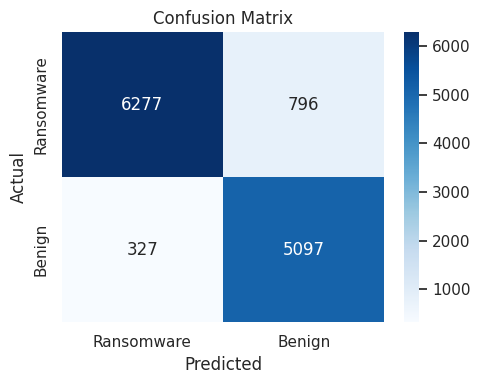

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ransomware", "Benign"], yticklabels=["Ransomware", "Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


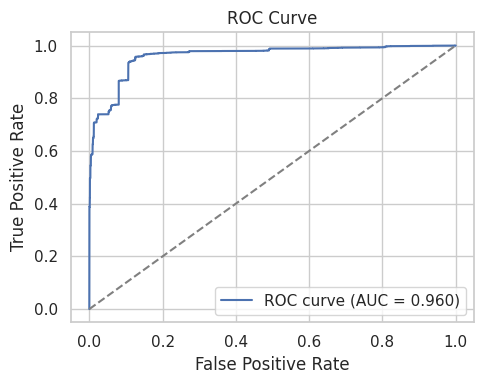

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


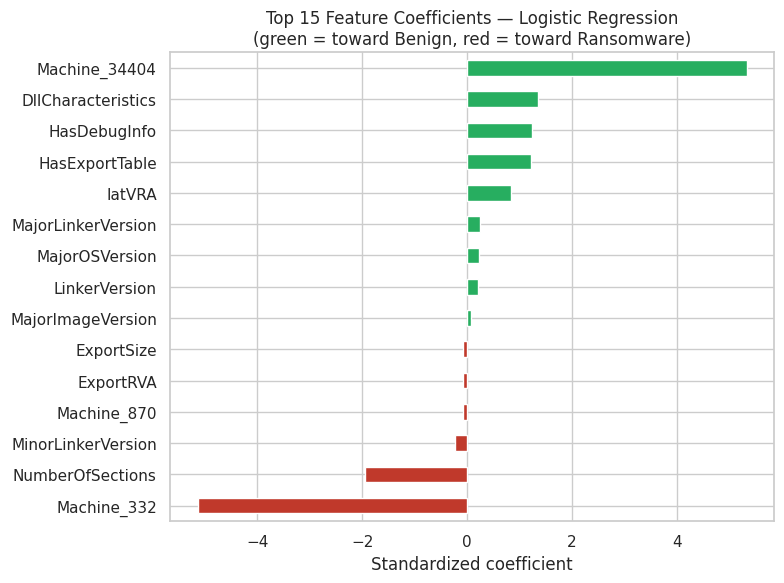

,0
Machine_34404,5.325426
Machine_332,-5.143010
NumberOfSections,-1.943445
DllCharacteristics,1.339633
HasDebugInfo,1.227023
HasExportTable,1.219983
IatVRA,0.831077
MajorLinkerVersion,0.242865
MinorLinkerVersion,-0.225795
MajorOSVersion,0.223721


In [17]:
coefs = pd.Series(best_logreg.coef_[0], index=feature_cols)
importances = coefs.reindex(coefs.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 6))
colors = importances.head(15).apply(lambda v: "#27ae60" if v > 0 else "#c0392b")
importances.head(15).sort_values().plot(kind="barh", color=colors.reindex(importances.head(15).sort_values().index))
plt.title("Top 15 Feature Coefficients — Logistic Regression\n(green = toward Benign, red = toward Ransomware)")
plt.xlabel("Standardized coefficient")
plt.tight_layout()
plt.show()

importances.head(15)


## 10. Save Model
Persist the trained pipeline components so they can be reloaded for evaluation on
the full dataset or deployed in a simple inference script.

In [18]:
os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_logreg, "artifacts/logistic_regression_ransomware_model.joblib")
joblib.dump(scaler, "artifacts/feature_scaler.joblib")
joblib.dump(feature_cols, "artifacts/feature_columns.joblib")
print("Saved model, scaler, and feature column list to ./artifacts/")


Saved model, scaler, and feature column list to ./artifacts/


In [19]:
from pathlib import Path
import json
import joblib
import numpy as np
import sklearn
import pandas as pd
from zipfile import ZipFile, ZIP_DEFLATED

required = ['best_logreg', 'scaler', 'feature_cols', 'X_test', 'y_test', 'X_train']
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError('Missing trained variables: ' + ', '.join(missing) +
                       '. Restore your trained session. Running the notebook again will train a NEW model.')
out = Path('artifacts')
out.mkdir(exist_ok=True)
joblib.dump(best_logreg, out / 'logistic_regression_ransomware_model.joblib')
joblib.dump(scaler, out / 'feature_scaler.joblib')
joblib.dump(feature_cols, out / 'feature_columns.joblib')
metadata = {
    'data_source': globals().get('DATA_SOURCE', 'Not recorded'),
    'best_params': best_logreg.get_params(),
    'train_rows': len(X_train),
    'test_y': np.asarray(y_test, dtype=int).tolist(),
    'ransomware_probability': best_logreg.predict_proba(X_test)[:, list(best_logreg.classes_).index(0)].tolist(),
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__,
}
(out / 'evaluation.json').write_text(json.dumps(metadata, indent=2))
with ZipFile('notebook_artifacts.zip', 'w', ZIP_DEFLATED) as archive:
    for name in ['logistic_regression_ransomware_model.joblib', 'feature_scaler.joblib', 'feature_columns.joblib', 'evaluation.json']:
        archive.write(out / name, 'artifacts/' + name)
print('Exported notebook_artifacts.zip. Data source:', metadata['data_source'])
print('Use scikit-learn', sklearn.__version__, 'when deploying this model.')
print('No model training was performed by this export cell.')


Exported notebook_artifacts.zip. Data source: kagglehub
Use scikit-learn 1.6.1 when deploying this model.
No model training was performed by this export cell.
